# 작품별 회차 기울기 점수

1~5화의 초기 이탈과 무료→유료 전환 회차를 제외합니다. `QuantileTransformer`로 무료·유료 기울기 분포를 각각 0~1 백분위로 변환하고, 방향을 뒤집어 완만할수록 100점에 가깝게 계산합니다.

In [1]:
from pathlib import Path
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import QuantileTransformer

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'db' / 'data').exists() else Path.cwd().parent
WORK_IDS = {
    '무료 작품': 516904,  # 일면식도 없던 친척에게 1조 원을 상속받았다
    '유료 전환 작품': 520318,  # 비자발적 종신 독재자
}
works_path = PROJECT_ROOT / 'db' / 'data' / 'works.csv'
episodes_path = PROJECT_ROOT / 'db' / 'data' / 'episodes.csv'

works_parts = []
for chunk in pd.read_csv(works_path, usecols=['work_id', 'title'], chunksize=10_000):
    matched = chunk.loc[chunk['work_id'].isin(WORK_IDS.values())]
    if not matched.empty:
        works_parts.append(matched)
works = pd.concat(works_parts, ignore_index=True).set_index('work_id')

episode_parts = []
columns = ['work_id', 'episode_number', 'access_type', 'view_count']
for chunk in pd.read_csv(episodes_path, usecols=columns, chunksize=100_000):
    matched = chunk.loc[chunk['work_id'].isin(WORK_IDS.values())]
    if not matched.empty:
        episode_parts.append(matched)
episodes = pd.concat(episode_parts, ignore_index=True).sort_values(['work_id', 'episode_number'])

In [2]:
INITIAL_EXCLUDE_END = 25

def calculate_episode_scores(work_episodes):
    rows = work_episodes.sort_values('episode_number').reset_index(drop=True)
    result = []
    for i in range(1, len(rows)):
        previous, current = rows.iloc[i - 1], rows.iloc[i]
        if current['episode_number'] <= INITIAL_EXCLUDE_END:
            continue  # 초기 1~5화 제외
        if previous['access_type'] != current['access_type']:
            continue  # 무료→유료 전환 기울기 제외
        if current['view_count'] <= 0:
            decline_rate = 1.0  # 조회수 0은 완전 이탈로 처리
        elif previous['view_count'] <= 0:
            continue
        else:
            decline_rate = max(0.0, (previous['view_count'] - current['view_count']) / previous['view_count'])
        angle = 90.0 if decline_rate >= 1 else math.degrees(math.atan2(decline_rate, 1 - decline_rate))
        score = np.nan  # 전체 기울기 분포를 구한 뒤 아래에서 계산
        result.append({
            '회차': int(current['episode_number']),
            '구간': current['access_type'],
            '직전 조회수': int(previous['view_count']),
            '현재 조회수': int(current['view_count']),
            '감소율': decline_rate,
            '각도': angle,
            '점수': score,
        })
    return pd.DataFrame(result)

scores = {}
for label, work_id in WORK_IDS.items():
    work_scores = calculate_episode_scores(episodes.loc[episodes['work_id'].eq(work_id)])
    scores[label] = work_scores

# 무료·유료 기울기 분포를 QuantileTransformer로 각각 학습
all_scores = pd.concat(scores, names=['작품 유형', '원래 인덱스']).reset_index(level=[0, 1])
angle_bounds = all_scores.groupby('구간')['각도'].quantile([0.05, 0.95]).unstack()
angle_bounds.columns = ['5% 각도', '95% 각도']
scalers = {}
for access_type, reference in all_scores.groupby('구간'):
    scaler = QuantileTransformer(
        n_quantiles=min(1000, len(reference)),
        output_distribution='uniform',
        random_state=42,
    )
    scaler.fit(reference[['각도']])
    scalers[access_type] = scaler

for work_scores in scores.values():
    for access_type, scaler in scalers.items():
        mask = work_scores['구간'].eq(access_type)
        if mask.any():
            percentile = scaler.transform(work_scores.loc[mask, ['각도']]).ravel()
            work_scores.loc[mask, '점수'] = 100 * (1 - percentile)

display(angle_bounds.round(2))

summary = []
for label, work_id in WORK_IDS.items():
    work_scores = scores[label]
    free_mean = work_scores.loc[work_scores['구간'].eq('FREE'), '점수'].mean()
    paid_mean = work_scores.loc[work_scores['구간'].eq('PAID'), '점수'].mean()
    summary.append({
        '작품': works.loc[work_id, 'title'], '계산 회차': len(work_scores),
        '무료 평균': free_mean, '유료 평균': paid_mean, '전체 평균': work_scores['점수'].mean(),
    })

score_summary = pd.DataFrame(summary).round(2)
display(score_summary)
for label, work_scores in scores.items():
    print(f'\n{label} - 점수가 가장 낮은 10개 회차')
    display(work_scores.nsmallest(10, '점수').round({'감소율': 3, '각도': 2, '점수': 2}))

,5% 각도,95% 각도
구간,,
FREE,0.0,5.70
PAID,0.0,1.59


,작품,계산 회차,무료 평균,유료 평균,전체 평균
0,일면식도 없던 친척에게 1조 원을 상속받았다,102,48.14,NaN,48.14
1,비자발적 종신 독재자,233,69.92,51.73,53.29



무료 작품 - 점수가 가장 낮은 10개 회차


,회차,구간,직전 조회수,현재 조회수,감소율,각도,점수
18,24,FREE,5708,4824,0.155,10.38,0.00
6,12,FREE,12835,11298,0.120,7.75,0.83
64,70,FREE,1278,1128,0.117,7.57,1.65
19,25,FREE,4824,4265,0.116,7.47,2.48
11,17,FREE,9835,8701,0.115,7.43,3.31
15,21,FREE,6995,6276,0.103,6.54,4.13
14,20,FREE,7694,6995,0.091,5.71,4.96
21,27,FREE,3902,3559,0.088,5.50,5.79
20,26,FREE,4265,3902,0.085,5.31,6.61
29,35,FREE,2990,2743,0.083,5.15,7.44



유료 전환 작품 - 점수가 가장 낮은 10개 회차


,회차,구간,직전 조회수,현재 조회수,감소율,각도,점수
232,239,PAID,5457,4506,0.174,11.92,0.00
231,238,PAID,5807,5457,0.060,3.67,0.47
230,237,PAID,6152,5807,0.056,3.40,0.94
192,199,PAID,10483,9912,0.054,3.30,1.42
229,236,PAID,6365,6152,0.033,1.98,1.89
224,231,PAID,7083,6860,0.031,1.86,2.36
94,101,PAID,21604,20937,0.031,1.82,2.83
177,184,PAID,11088,10763,0.029,1.73,3.30
197,204,PAID,9685,9406,0.029,1.70,3.77
189,196,PAID,10646,10342,0.029,1.68,4.25


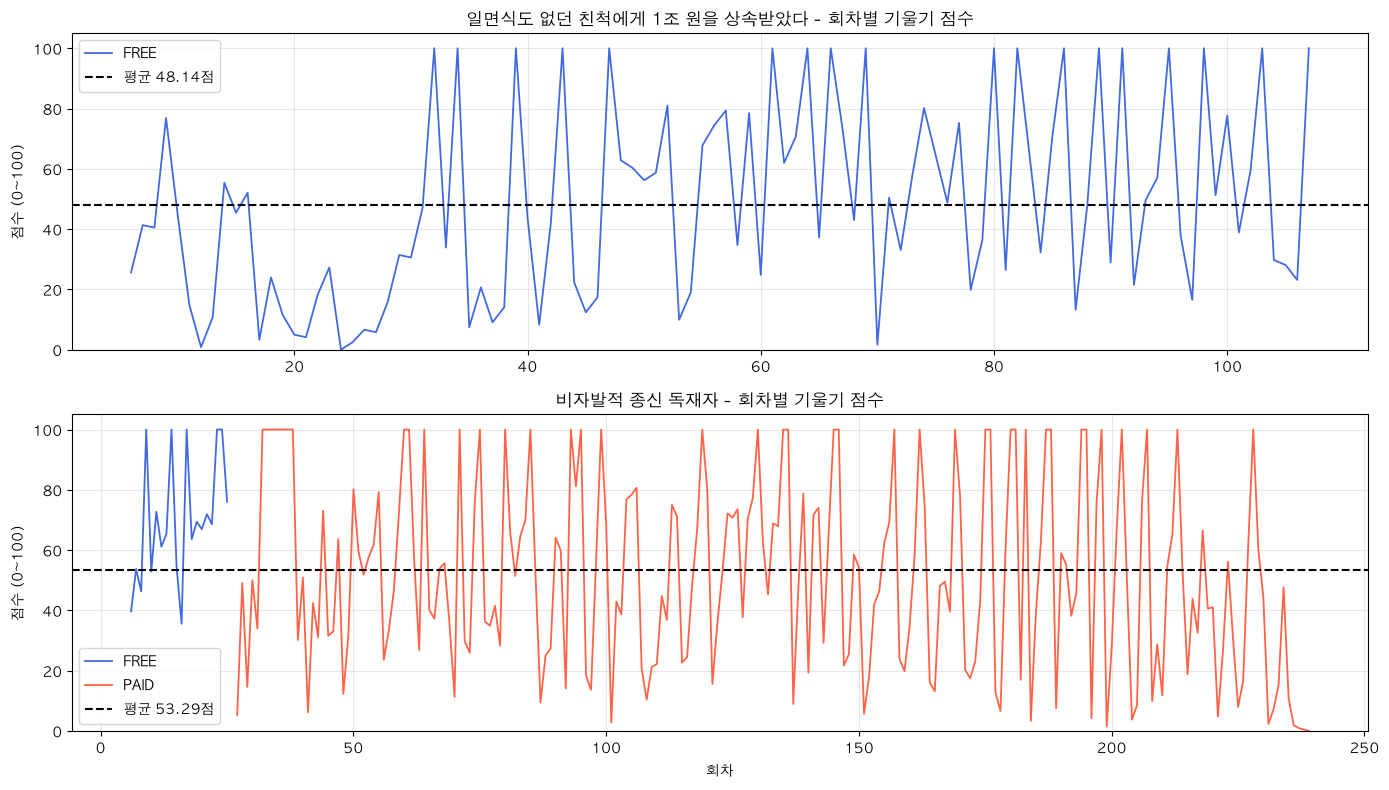

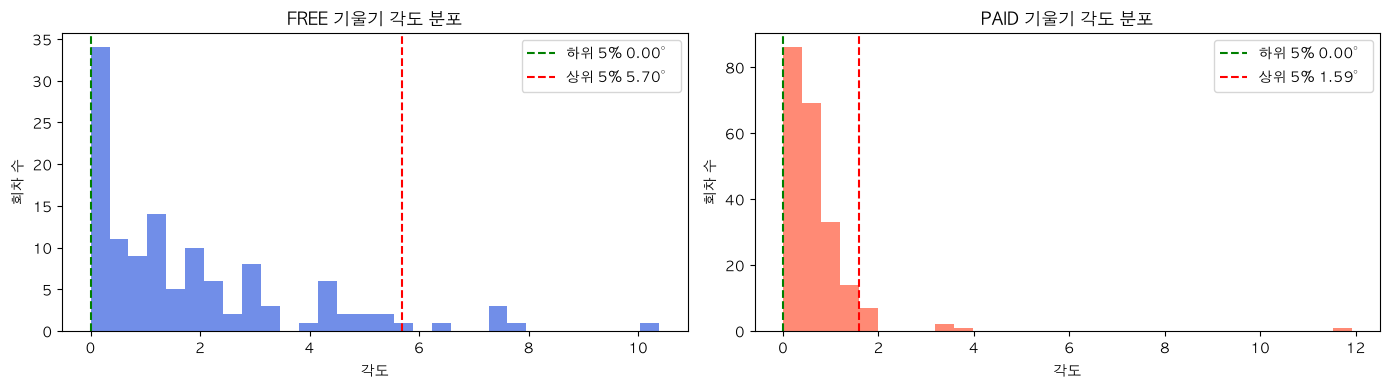

In [3]:
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharey=True)
colors = {'FREE': 'royalblue', 'PAID': 'tomato'}

for ax, (label, work_id) in zip(axes, WORK_IDS.items()):
    work_scores = scores[label]
    for access_type, part in work_scores.groupby('구간'):
        ax.plot(part['회차'], part['점수'], color=colors[access_type], linewidth=1.3, label=access_type)
    mean_score = work_scores['점수'].mean()
    ax.axhline(mean_score, color='black', linestyle='--', label=f'평균 {mean_score:.2f}점')
    ax.set_title(f"{works.loc[work_id, 'title']} - 회차별 기울기 점수")
    ax.set_ylabel('점수 (0~100)')
    ax.set_ylim(0, 105)
    ax.grid(alpha=0.3)
    ax.legend()
axes[1].set_xlabel('회차')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, access_type in zip(axes, ['FREE', 'PAID']):
    values = all_scores.loc[all_scores['구간'].eq(access_type), '각도']
    low, high = angle_bounds.loc[access_type, ['5% 각도', '95% 각도']]
    ax.hist(values, bins=30, color=colors[access_type], alpha=0.75)
    ax.axvline(low, color='green', linestyle='--', label=f'하위 5% {low:.2f}°')
    ax.axvline(high, color='red', linestyle='--', label=f'상위 5% {high:.2f}°')
    ax.set_title(f'{access_type} 기울기 각도 분포')
    ax.set_xlabel('각도')
    ax.set_ylabel('회차 수')
    ax.legend()
plt.tight_layout()
plt.show()